In [70]:
from astropy.table import Table
import numpy as np
import matplotlib.pyplot as plt
import glob
import os
import fitsio
import healpy
from scipy.spatial import cKDTree
from astropy.cosmology import Planck18 as cosmo
from mpl_toolkits.mplot3d import Axes3D
import astropy.units as u
import astropy.constants as const
import matplotlib
import astropy.io.ascii

In [24]:
file = "/global/cfs/cdirs/desi/spectro/redux/kibo/zcatalog/v1/zpix-sv3-dark.fits"
columns = ['TARGET_RA','TARGET_DEC','Z','ZWARN','TARGETID', 'HEALPIX', 'CHI2','DELTACHI2', 'SPECTYPE','MORPHTYPE', 'FLUX_G','FLUX_R','FLUX_Z','EBV','FLUX_W1','FLUX_W2','FIBERFLUX_G','FIBERFLUX_R','FIBERFLUX_Z',"SV3_DESI_TARGET",'DESI_TARGET','BGS_TARGET']
sp = Table(fitsio.read(file, columns=columns))

In [26]:
#select LRGs and ELGs based on a bitmask
#include a redshift cut: 0.75 < z < 1
zmin = 0.75
zmax = 1
lrgsecondaries = sp[(sp["SV3_DESI_TARGET"]&0x1==0x1)&(sp["ZWARN"]==0)&(sp["Z"] > 0.75)&(sp["Z"] < 1)]
elgsecondaries = sp[(sp["SV3_DESI_TARGET"]&0x2==0x2)&(sp["ZWARN"]==0)&(sp["Z"] > 0.75)&(sp["Z"] < 1)]
both = sp[(sp["SV3_DESI_TARGET"]&0x3==0x3)&(sp["ZWARN"]==0)&(sp["Z"] > 0.75)&(sp["Z"] < 1)]
print("Number of LRGs "+str(zmin)+" < z < "+str(zmax)+": "+str(len(lrgsecondaries)))
print("Number of ELGs "+str(zmin)+" < z < "+str(zmax)+": "+str(len(elgsecondaries)))
print("Number of galaxies identified as both ELG and LRG: "+str(len(both)))

Number of LRGs 0.75 < z < 1: 56683
Number of ELGs 0.75 < z < 1: 101469
Number of galaxies identified as both ELG and LRG: 232


In [29]:
def raDecToUnitSphere(a, d):
    a = a*np.pi/180
    d = d*np.pi/180
    x = np.cos(a)*np.cos(d)
    y = np.sin(a)*np.cos(d)
    z = np.sin(d)
    return x,y,z

def raDecToCartesian(a, d, r):
    return r*raDecToUnitSphere(a,d)

In [30]:
#get comoving distances of galaxies along line of sight
elgsecondaries['d'] = cosmo.comoving_distance(elgsecondaries['Z'])
lrgsecondaries['d'] = cosmo.comoving_distance(lrgsecondaries['Z'])

'''
#get coordinates of galaxies on the unit sphere
elg['x_us'],elg['y_us'],elg['z_us'] = raDecToUnitSphere(elg['TARGET_RA'],elg['TARGET_DEC'])
lrg['x_us'],lrg['y_us'],lrg['z_us'] = raDecToUnitSphere(lrg['TARGET_RA'],lrg['TARGET_DEC'])
'''

#get Cartesian coordinates of galaxies
elgsecondaries['x'],elgsecondaries['y'],elgsecondaries['z'] = raDecToCartesian(elgsecondaries['TARGET_RA'],elgsecondaries['TARGET_DEC'],elgsecondaries['d'])
lrgsecondaries['x'],lrgsecondaries['y'],lrgsecondaries['z'] = raDecToCartesian(lrgsecondaries['TARGET_RA'],lrgsecondaries['TARGET_DEC'],lrgsecondaries['d'])

In [245]:
elgsecondaries[:5]

TARGETID,HEALPIX,Z,ZWARN,CHI2,SPECTYPE,DELTACHI2,TARGET_RA,TARGET_DEC,MORPHTYPE,EBV,FLUX_G,FLUX_R,FLUX_Z,FLUX_W1,FLUX_W2,FIBERFLUX_G,FIBERFLUX_R,FIBERFLUX_Z,SV3_DESI_TARGET,DESI_TARGET,BGS_TARGET,d,x,y,z
,,,,,,,,,,,,,,,,,,,,,,Mpc,,,
int64,int32,float64,int64,float64,str6,float64,float64,float64,str4,float32,float32,float32,float32,float32,float32,float32,float32,float32,int64,int64,int64,float64,float64,float64,float64
39633166985595308,10016,0.7513549659607258,0,7528.527903616428,GALAXY,14.687861621379852,246.04503868889282,45.121657927872164,PSF,0.00817365,0.3746547,0.36090985,0.4738166,1.1296707,-1.28244,0.29180017,0.28109497,0.36903253,4674,0,0,2729.63146943488,-782.0069738344285,-1760.138748937469,1934.2348968758638
39633166985595913,10016,0.8540273677390846,0,8481.284338235855,GALAXY,238.11162900924683,246.09560214941203,45.104057467601805,REX,0.008474668,0.5014288,0.709836,1.6706669,2.9614477,0.27436718,0.27098992,0.3836206,0.9028877,2594,0,0,3016.7173703489607,-862.8026929413028,-1946.6215380187346,2137.011884229931
39633301257849662,10145,0.8034192670791538,0,8347.395320296288,GALAXY,195.24259012192488,244.31778646775948,53.521859966593475,REX,0.012905114,0.58937263,0.74338907,1.3989066,2.6184058,2.6962464,0.2762488,0.3484389,0.6556909,4674,0,0,2877.4345176200545,-741.3738036293838,-1541.6855619180612,2313.698319716045
39633301241070680,10146,0.8924782967872618,0,7925.60083758831,GALAXY,192.9549601972103,242.4707706827426,53.477408103350434,REX,0.009431442,0.35915747,0.3516303,0.91409814,1.2367637,0.19729826,0.2394525,0.2344341,0.60943484,4674,0,0,3119.745914127779,-858.1616169810598,-1646.461831158823,2507.0972550729975
39633301241070445,10146,0.9436069710627268,0,7783.952706634998,GALAXY,408.6144741177559,242.44998503577034,53.55779938914883,DEV,0.011831268,0.8346308,1.2500141,2.768885,4.875839,1.7821116,0.3978738,0.5958896,1.319945,2594,0,0,3253.1304915053356,-893.7775967380502,-1713.2776341720878,2617.0019775645173


### Cylinders ###
For each galaxy, we define a (true) cylinder with axis along the line of sight of radius $R_{CiC}$ and height $L_{CiC}$. For this first analysis we choose $R_{CiC} = 1 \text{ Mpc/h}$, $L_{CiC} = 20 \text{ Mpc/h}$.

### Search Method ###
We will search for galaxy pairs with cKDTree's query_ball_point. First we will convert right ascension, declination, and redshift to Cartesian coordinates for each galaxy. Then we will find all the other galaxies in a sphere of radius $\sqrt{(L_{CiC}/2)^2+R_{CiC}}$ around that galaxy. Next we will prune out neighbor galaxies not in the truncated cone.

### Running Questions List ###

- Is there any bias to how the rosette locations were selected?
- What's wrong with the center of the rosettes?

In [49]:
cylh = 20 #cylinder height in Mpc
cyld = 2 #cylinder diameter in Mpc
def checkAngularSep(phi1,phi2,theta1,theta2,psimin,psimax):
    #arguments: RA1, RA2, Dec1, Dec2, min separation, max separation (in DEGREES)
    theta1 = theta1*np.pi/180
    theta2 = theta2*np.pi/180
    phi1 = phi1*np.pi/180
    phi2 = phi2*np.pi/180
    psimin = psimin*np.pi/180
    psimax = psimax*np.pi/180
    cospsi = np.sin(theta1)*np.sin(theta2)+np.cos(theta1)*np.cos(theta2)*np.cos(phi1-phi2)
    return (cospsi**2 > np.cos(psimax)**2)&(cospsi**2 < np.cos(psimin)**2)
def rosetteOR(table, psimin, psimax, rosettes):
    return np.any([checkAngularSep(rosettes['RA'][i],table['TARGET_RA'],rosettes['Dec'][i],table['TARGET_DEC'],psimin,psimax)
                   for i in range(len(rosettes['RA']))],axis=0)
def checkZBoundary(table,zmin,zmax):
    return (table['d'] > cosmo.comoving_distance(zmin)+cylh/2*u.Mpc)&(table['d'] < cosmo.comoving_distance(zmax)-cylh/2*u.Mpc)

def makePrimaries(table, zmin, zmax, psimin, psimax, rosettes):
    return checkZBoundary(table,zmin,zmax)&rosetteOR(table,psimin,psimax,rosettes)

In [50]:
rosettes = {'RA': [150.100, 179.600, 183.100, 189.900, 194.750, 210.000, 215.500, 217.800, 216.300, 219.800, 218.050, 
             242.750, 241.050, 245.880, 252.500, 269.730, 194.750, 212.800, 269.730, 236.100],
            'Dec': [2.182, 0.000, 0.000, 61.800, 28.200, 5.000, 52.500, 34.400, 0.600, 0.600, 2.430, 54.980, 43.450, 43.450,
              34.500, 66.020, 24.700, 0.600, 62.520, 43.450] }

In [51]:
psimin = 0.2
psimax = 1.5
zmin = 0.75
zmax = 1
rsphere = np.sqrt((cylh/2)**2+(cyld/2)**2) #radius of the sphere of our initial search
elgprimaries = elgsecondaries[makePrimaries(elgsecondaries,zmin,zmax,psimin,psimax,rosettes)]
lrgprimaries = lrgsecondaries[makePrimaries(lrgsecondaries,zmin,zmax,psimin,psimax,rosettes)]

In [36]:
elgsecondaries['d'][1]

3016.7173703489607

79981


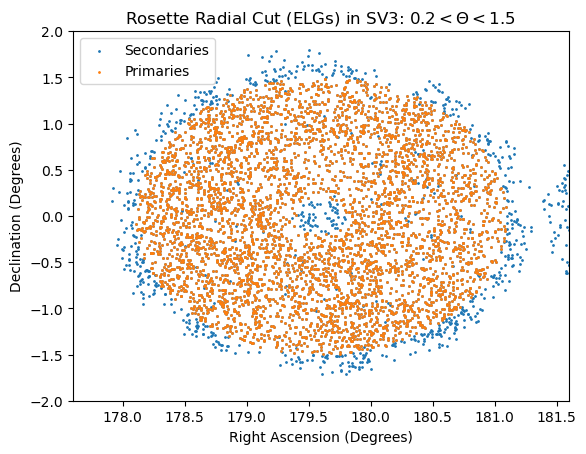

In [53]:
#try plotting some rosettes just to make sure we have what we want
plt.figure()
plt.xlim(rosettes['RA'][1]-2,rosettes['RA'][1]+2)
plt.ylim(rosettes['Dec'][1]-2,rosettes['Dec'][1]+2)
plt.title(r"Rosette Radial Cut (ELGs) in SV3: $0.2 < \Theta < 1.5$ ")
plt.scatter(elgsecondaries["TARGET_RA"],elgsecondaries["TARGET_DEC"],s=1,label="Secondaries")
plt.scatter(elgprimaries["TARGET_RA"],elgprimaries["TARGET_DEC"],s=1,label="Primaries")
plt.legend()
plt.xlabel("Right Ascension (Degrees)")
plt.ylabel("Declination (Degrees)")

print(len(elgprimaries))

plt.savefig("rosettecut.png")

In [54]:
#make 3D maps of galaxies
#primaries
elgprimarymap = np.transpose([elgprimaries['x'],elgprimaries['y'],elgprimaries['z']])
lrgprimarymap = np.transpose([lrgprimaries['x'],lrgprimaries['y'],lrgprimaries['z']])
#secondaries
elgsecondarymap = np.transpose([elgsecondaries['x'],elgsecondaries['y'],elgsecondaries['z']])
lrgsecondarymap = np.transpose([lrgsecondaries['x'],lrgsecondaries['y'],lrgsecondaries['z']])
#make ckdtrees
elgtree = cKDTree(elgsecondarymap)
lrgtree = cKDTree(lrgsecondarymap)

In [55]:
#search for neighbors
elgprimaries['neighbors'] = elgtree.query_ball_point(elgprimarymap, rsphere)
lrgprimaries['neighbors'] = lrgtree.query_ball_point(lrgprimarymap, rsphere)

#search for neighbors among other class of galaxies
elgprimaries['lrg_neighbors'] = lrgtree.query_ball_point(elgprimarymap, rsphere)
lrgprimaries['elg_neighbors'] = elgtree.query_ball_point(lrgprimarymap, rsphere)

In [56]:
#define pruning algorithm
hsq = cylh**2/4
dsq = cyld**2/4

def checkcylinder(x1,y1,z1,d1,x2,y2,z2,d2):
    #check if two points are in cylinder with axis along line of sight
    dDsq = (d1 - d2)**2
    if dDsq > hsq: return False
    elif (x1 - x2)**2 + (y1 - y2)**2 + (z1 - z2)**2 - dDsq > dsq: 
        return False
    else: return True

def tableprune(table1, table2, i, j):
    #i is the index of the primary galaxy (in table 1)
    #j is the index of the secondary galaxy (in table 2)
    return checkcylinder(table1[i]['x'],table1[i]['y'],table1[i]['z'],table1[i]['d'],
                         table2[j]['x'],table2[j]['y'],table2[j]['z'],table2[j]['d'])

In [57]:
#prune trees:
elgprimaries['neighborspruned'] = [np.array(elgprimaries[i]['neighbors'])[[tableprune(elgprimaries,elgsecondaries,i,j)
            for j in elgprimaries[i]['neighbors']]][1:] for i in range(len(elgprimaries))]
lrgprimaries['neighborspruned'] = [np.array(lrgprimaries[i]['neighbors'])[[tableprune(lrgprimaries,lrgsecondaries,i,j)
            for j in lrgprimaries[i]['neighbors']]][1:] for i in range(len(lrgprimaries))]
elgprimaries['lrg_neighborspruned'] = [np.array(elgprimaries[i]['lrg_neighbors'])[[tableprune(elgprimaries,lrgsecondaries,i,j)
            for j in elgprimaries[i]['lrg_neighbors']]] for i in range(len(elgprimaries))]
lrgprimaries['elg_neighborspruned'] = [np.array(lrgprimaries[i]['elg_neighbors'])[[tableprune(lrgprimaries,elgsecondaries,i,j) 
            for j in lrgprimaries[i]['elg_neighbors']]] for i in range(len(lrgprimaries))]

In [58]:
#count up the galaxies in cylinders
elgprimaries['N_CiC'] = [len(n) for n in elgprimaries['neighborspruned']]
lrgprimaries['N_CiC'] = [len(n) for n in lrgprimaries['neighborspruned']]
elgprimaries['N_lrgCiC'] = [len(n) for n in elgprimaries['lrg_neighborspruned']]
lrgprimaries['N_elgCiC'] = [len(n) for n in lrgprimaries['elg_neighborspruned']]

In [59]:
bins = np.arange(zmin,zmax,0.05)
elgNCiCavg = [np.averag(elgprimaries[(elgprimaries['Z'] > bins[b])&(elgprimaries['Z'] < bins[b+1])]['N_CiC'])
              for b in range(len(bins)-1)]

plt.figure()
plt.plot(bins,elgNCiCavg) #should these be uncorrelated?
plt.title("ELG Counts in Cylinders vs. Redshift")
plt.ylabel(r'N_{CiC}')
plt.xlabel('z')
plt.yscale('log')
'''
plt.figure()
plt.scatter(lrg['Z'],lrg['N_CiC']) #should these be uncorrelated?
plt.title("LRG Counts in Cylinders vs. Redshift")
plt.ylabel(r'N_{CiC}')
plt.xlabel('z')
plt.yscale('log')

plt.figure()
plt.title("ELG and LRG Redshifts in DESI SV3")
plt.hist(elg["Z"],bins=100,label="ELG",alpha=0.7)
plt.xlabel("Redshift")
plt.ylabel("Galaxies")

plt.hist(lrg["Z"],bins=100,label="LRG",alpha=0.7)
plt.legend()
plt.yscale("log")'''

AttributeError: module 'numpy' has no attribute 'averag'

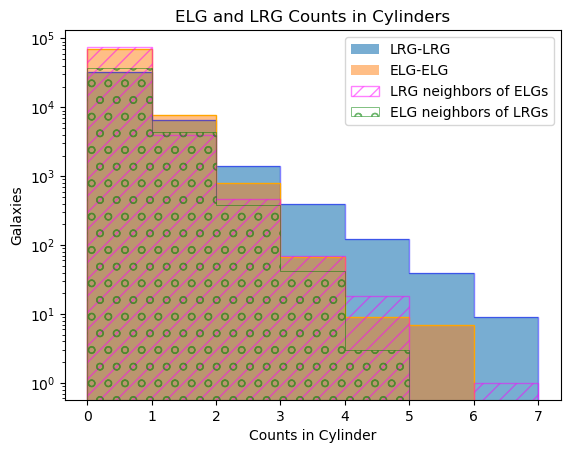

In [60]:
#check CiC distribution
plt.figure()
plt.title("ELG and LRG Counts in Cylinders")

plt.hist(lrgprimaries["N_CiC"],label="LRG-LRG",alpha=0.6,bins=np.arange(0,8))
#plot edge
plt.hist(lrgprimaries["N_CiC"],bins=np.arange(0,8),histtype = 'step',color='blue',alpha=0.5)

plt.hist(elgprimaries["N_CiC"],label="ELG-ELG",alpha=0.5,bins=np.arange(0,8))
plt.hist(elgprimaries["N_CiC"],bins=np.arange(0,8),histtype='step',color='orange')

plt.hist(elgprimaries["N_lrgCiC"],label="LRG neighbors of ELGs",bins=np.arange(0,8),histtype='step',hatch = '//',color='magenta',alpha=0.5)
plt.hist(lrgprimaries["N_elgCiC"],label="ELG neighbors of LRGs",bins=np.arange(0,8),histtype= 'step',hatch = 'o',color='g',alpha=0.5,linewidth=0.7)
plt.xlabel("Counts in Cylinder")
plt.ylabel("Galaxies")

plt.legend()
plt.yscale("log")
plt.savefig("CiC.png")

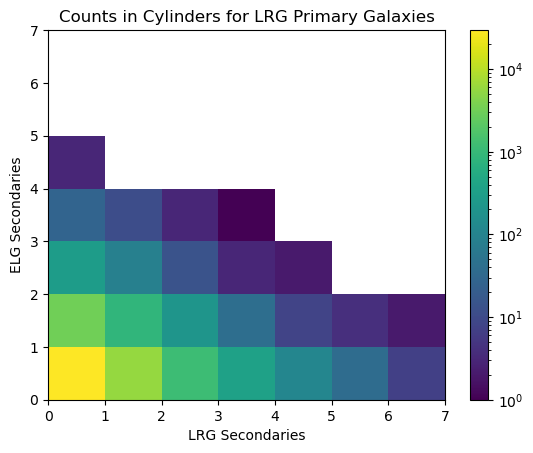

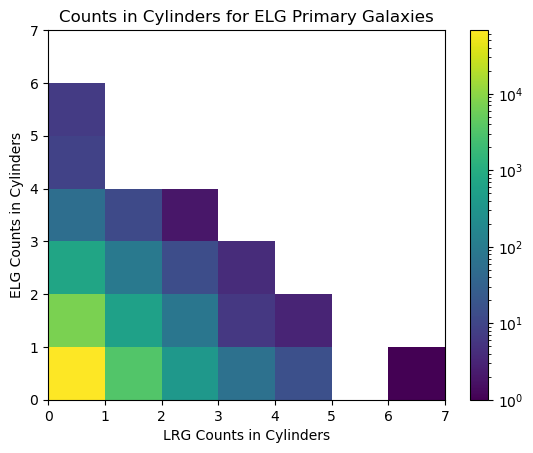

In [61]:
plt.figure()
plt.title("Counts in Cylinders for LRG Primary Galaxies")
plt.hist2d(lrgprimaries["N_CiC"],lrgprimaries["N_elgCiC"],bins=np.arange(0,8),norm=matplotlib.colors.LogNorm())
plt.colorbar()
plt.xlabel("LRG Secondaries")
plt.ylabel("ELG Secondaries")
plt.savefig("2dLRGCiC.png")

plt.figure()
plt.title("Counts in Cylinders for ELG Primary Galaxies")
plt.hist2d(elgprimaries["N_lrgCiC"],elgprimaries["N_CiC"],bins=np.arange(0,8),norm=matplotlib.colors.LogNorm())
plt.colorbar()
plt.xlabel("LRG Counts in Cylinders")
plt.ylabel("ELG Counts in Cylinders")
plt.savefig("2dELGCiC.png")

/tmp/ipykernel_1283905/733330509.py:22: RuntimeWarning: divide by zero encountered in log10
  ax.bar3d(xpos, ypos, zpos, dx, dy, np.log10(dz), zsort='average',color='pink')


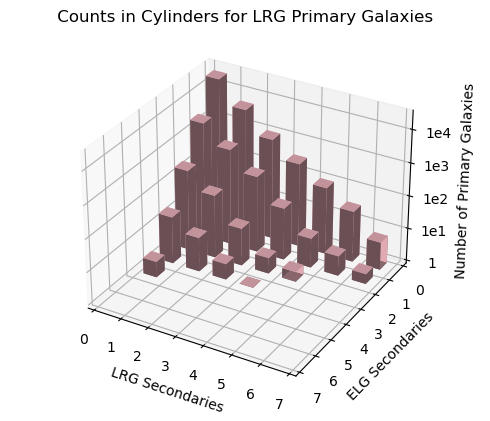

<Figure size 640x480 with 0 Axes>

In [64]:
#try the same thing but in 3D
fig = plt.figure()
ax = fig.add_subplot(projection='3d')
hist, xedges, yedges = np.histogram2d(lrgprimaries["N_CiC"],lrgprimaries["N_elgCiC"],bins=np.arange(0,8))

# Construct arrays for the anchor positions of the 16 bars.
xpos, ypos = np.meshgrid(xedges[:-1] + 0.25, yedges[:-1] + 0.25, indexing="ij")
xpos = xpos.ravel()
ypos = ypos.ravel()
zpos = 0


zticks = [1,1e1,1e2,1e3,1e4]
ax.set_zticks(np.log10(zticks))
ax.set_zticklabels(["1","1e1","1e2","1e3","1e4"])


# Construct arrays with the dimensions for the 16 bars.
dx = dy = 0.5 * np.ones_like(zpos)
dz = hist.ravel()
#ax.set_zscale('symlog')
ax.bar3d(xpos, ypos, zpos, dx, dy, np.log10(dz), zsort='average',color='pink')
ax.set_xlabel("LRG Secondaries")
ax.set_ylabel("ELG Secondaries")
ax.set_zlabel("Number of Primary Galaxies")
ax.set_title("         Counts in Cylinders for LRG Primary Galaxies         ")
#ax.invert_xaxis()
ax.invert_yaxis()

plt.show()
plt.savefig("3DLRGCiC.pdf")

/tmp/ipykernel_1283905/602070716.py:22: RuntimeWarning: divide by zero encountered in log10
  ax.bar3d(xpos, ypos, zpos, dx, dy, np.log10(dz), zsort='average',color='orange')


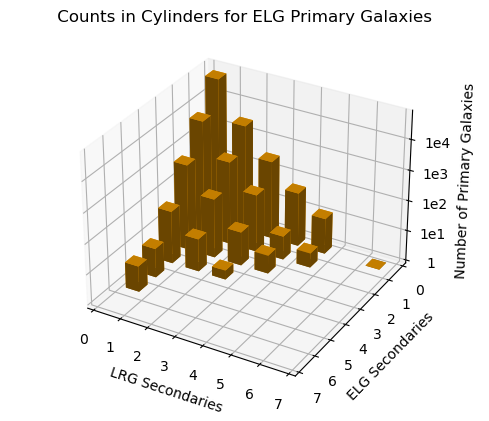

<Figure size 640x480 with 0 Axes>

In [66]:
#try the same thing but in 3D
fig = plt.figure()
ax = fig.add_subplot(projection='3d')
hist, xedges, yedges = np.histogram2d(elgprimaries["N_lrgCiC"],elgprimaries["N_CiC"],bins=np.arange(0,8))

# Construct arrays for the anchor positions of the 16 bars.
xpos, ypos = np.meshgrid(xedges[:-1] + 0.25, yedges[:-1] + 0.25, indexing="ij")
xpos = xpos.ravel()
ypos = ypos.ravel()
zpos = 0


zticks = [1,1e1,1e2,1e3,1e4]
ax.set_zticks(np.log10(zticks))
ax.set_zticklabels(["1","1e1","1e2","1e3","1e4"])


# Construct arrays with the dimensions for the 16 bars.
dx = dy = 0.5 * np.ones_like(zpos)
dz = hist.ravel()
#ax.set_zscale('symlog')
ax.bar3d(xpos, ypos, zpos, dx, dy, np.log10(dz), zsort='average',color='orange')
ax.set_xlabel("LRG Secondaries")
ax.set_ylabel("ELG Secondaries")
ax.set_zlabel("Number of Primary Galaxies")
ax.set_title("         Counts in Cylinders for ELG Primary Galaxies         ")
#ax.invert_xaxis()
ax.invert_yaxis()

plt.show()
plt.savefig("3DELGCiC.pdf")

In [72]:
#save our results
elgtowrite = elgprimaries['N_CiC','N_lrgCiC','x','y','z','Z','TARGET_RA','TARGET_DEC']
lrgtowrite = lrgprimaries['N_CiC','N_elgCiC','x','y','z','Z','TARGET_RA','TARGET_DEC']

astropy.io.ascii.write(elgtowrite, 'datafiles/sv3_elg.csv', overwrite=True,format='csv')
astropy.io.ascii.write(lrgtowrite, 'datafiles/sv3_lrg.csv', overwrite=True,format='csv')